# 01 — Exploratory Data Analysis
### Fake News Detection — Fake & Real News Dataset (Kaggle)

**Goal of this notebook:** understand the raw data before touching any modeling code —
class balance, text length patterns, vocabulary differences between fake/real articles,
and any data-quality issues (duplicates, leakage) that need to be handled in preprocessing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data"


## 1. Load & label the data

In [3]:
fake = pd.read_csv(f"{DATA_DIR}/Fake.csv")
true = pd.read_csv(f"{DATA_DIR}/True.csv")

fake["label"] = 0   # 0 = Fake
true["label"] = 1   # 1 = Real

print("Fake shape:", fake.shape)
print("True shape:", true.shape)

df = pd.concat([fake, true], axis=0, ignore_index=True)
df.sample(5, random_state=1)


Fake shape: (23481, 5)
True shape: (21417, 5)


,title,text,subject,date,label
4528,Trump Calls For This Racist Policy To Be Forc...,Donald Trump is calling for one of the most co...,News,"September 21, 2016",0
31727,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,"September 7, 2016",1
10937,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,"May 9, 2017",0
13470,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,"Jul 21, 2016",0
40814,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,"October 14, 2017",1


## 2. Basic structure & missing values

In [4]:
print(df.info())
print()
print("Missing values:\n", df.isnull().sum())
print()
print("Duplicate (title, text) rows:", df.duplicated(subset=["title", "text"]).sum())


<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB
None

Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate (title, text) rows: 5793


**Observation:** no missing values in any column. There are some duplicate
`(title, text)` rows across the two files — we drop these before splitting into
train/test later so the same article can't leak between the two sets.

## 3. Class balance

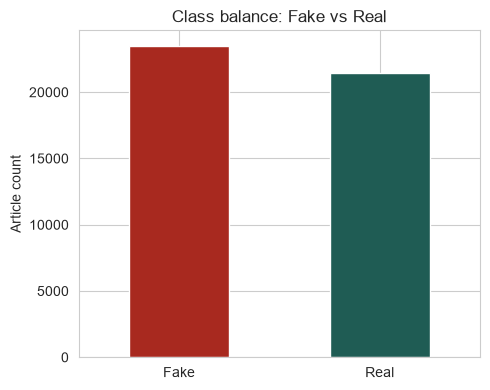

label
Fake    0.522985
Real    0.477015
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(5,4))
df["label"].map({0: "Fake", 1: "Real"}).value_counts().plot(kind="bar", color=["#a8291f", "#1f5c54"], ax=ax)
ax.set_title("Class balance: Fake vs Real")
ax.set_xlabel("")
ax.set_ylabel("Article count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df["label"].value_counts(normalize=True).rename({0:"Fake",1:"Real"}))


**Observation:** the dataset is fairly balanced (roughly 52% real / 48% fake),
so accuracy is a reasonably meaningful metric here — but we'll still track
precision/recall/F1 per class since a false negative (calling fake news "real")
is more costly than the reverse.

## 4. Subject / category breakdown — an important data-leakage warning

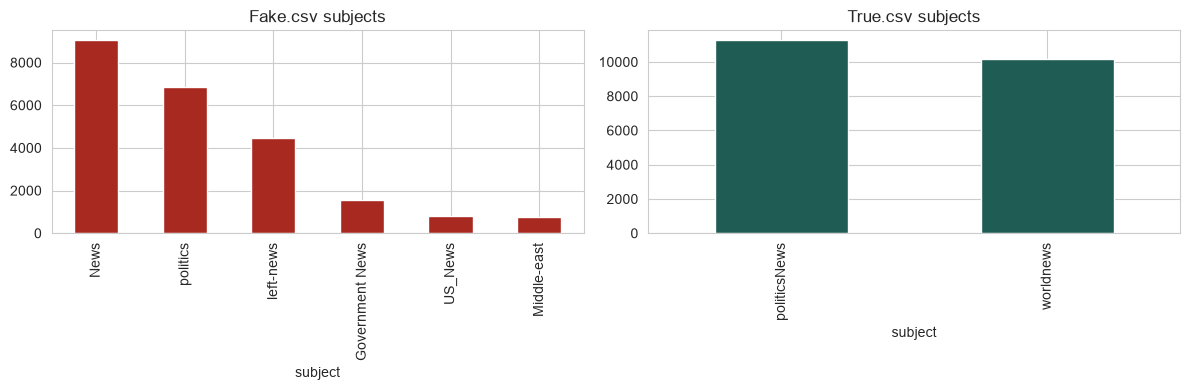

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
fake["subject"].value_counts().plot(kind="bar", ax=axes[0], color="#a8291f")
axes[0].set_title("Fake.csv subjects")
true["subject"].value_counts().plot(kind="bar", ax=axes[1], color="#1f5c54")
axes[1].set_title("True.csv subjects")
plt.tight_layout()
plt.show()


**Critical observation:** the `subject` column is a near-perfect predictor of the
label by construction — `Fake.csv` only contains subjects like `News`, `politics`,
`left-news`, while `True.csv` only contains `politicsNews` and `worldnews`. If we
fed `subject` into the model it would get ~100% accuracy without learning anything
about *what makes text sound fake* — that's data leakage. **We exclude `subject`
entirely from modeling.**

There's a second, subtler leakage source: almost every article in `True.csv` begins
with a `"CITY (Reuters) -"` byline, because the real articles were sourced from
Reuters. A model can trivially learn "contains the word *Reuters* → real" instead of
learning genuine linguistic patterns. We strip this byline out during text cleaning
(see notebook 02).

In [7]:
sample_true_text = true.loc[0, "text"]
print(sample_true_text[:180])


WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, calle


## 5. Text length distributions

C:\Users\new\AppData\Local\Temp\ipykernel_22372\2126671859.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="word_count",


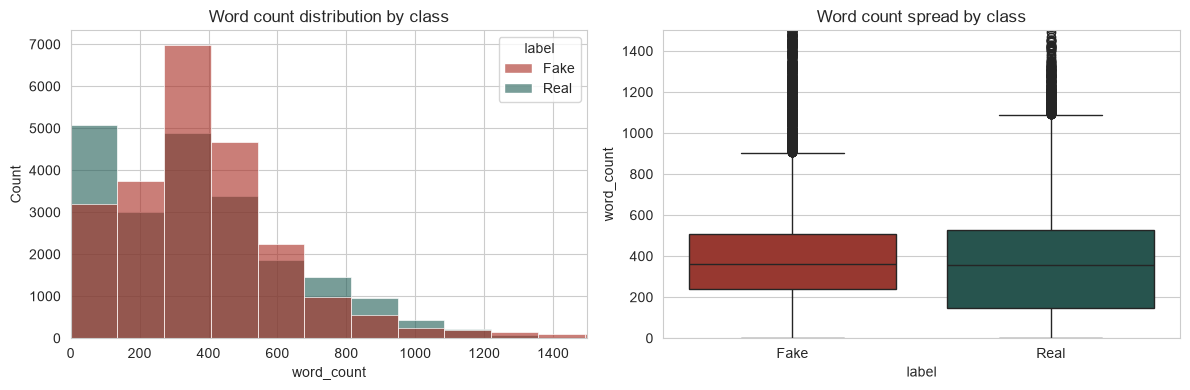

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23481.0,423.197905,408.388890,0.0,240.0,363.0,506.0,8135.0
1,21417.0,385.640099,274.006204,0.0,148.0,359.0,525.0,5172.0


In [8]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df, x="word_count", hue=df["label"].map({0:"Fake",1:"Real"}),
             bins=60, ax=axes[0], palette={"Fake":"#a8291f","Real":"#1f5c54"}, alpha=0.6)
axes[0].set_xlim(0, 1500)
axes[0].set_title("Word count distribution by class")

sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="word_count",
            ax=axes[1], palette={"Fake":"#a8291f","Real":"#1f5c54"})
axes[1].set_ylim(0, 1500)
axes[1].set_title("Word count spread by class")
plt.tight_layout()
plt.show()

df.groupby("label")["word_count"].describe()


## 6. Punctuation & style signals — early feature-engineering hints

C:\Users\new\AppData\Local\Temp\ipykernel_22372\3413316560.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="exclaim_count", ax=axes[0],
C:\Users\new\AppData\Local\Temp\ipykernel_22372\3413316560.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="upper_title_words", ax=axes[1],


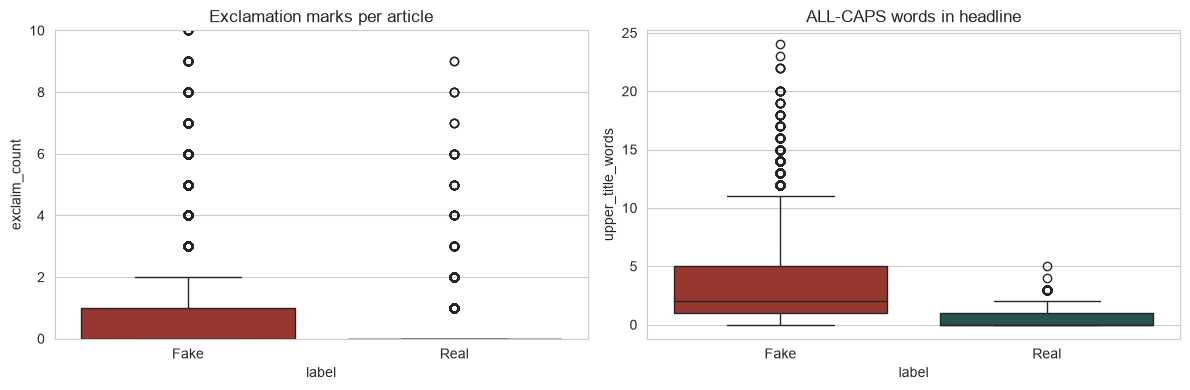

In [9]:
df["exclaim_count"] = df["text"].str.count("!")
df["upper_title_words"] = df["title"].apply(lambda t: sum(1 for w in str(t).split() if w.isupper() and len(w) > 1))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="exclaim_count", ax=axes[0],
            palette={"Fake":"#a8291f","Real":"#1f5c54"})
axes[0].set_ylim(0, 10)
axes[0].set_title("Exclamation marks per article")

sns.boxplot(data=df, x=df["label"].map({0:"Fake",1:"Real"}), y="upper_title_words", ax=axes[1],
            palette={"Fake":"#a8291f","Real":"#1f5c54"})
axes[1].set_title("ALL-CAPS words in headline")
plt.tight_layout()
plt.show()


**Observation:** fake articles use noticeably more exclamation marks and more
ALL-CAPS words in the headline — a classic clickbait/sensationalism signal. This
justifies including these as handcrafted features in notebook 02, alongside TF-IDF.

## 7. Word clouds — vocabulary differences

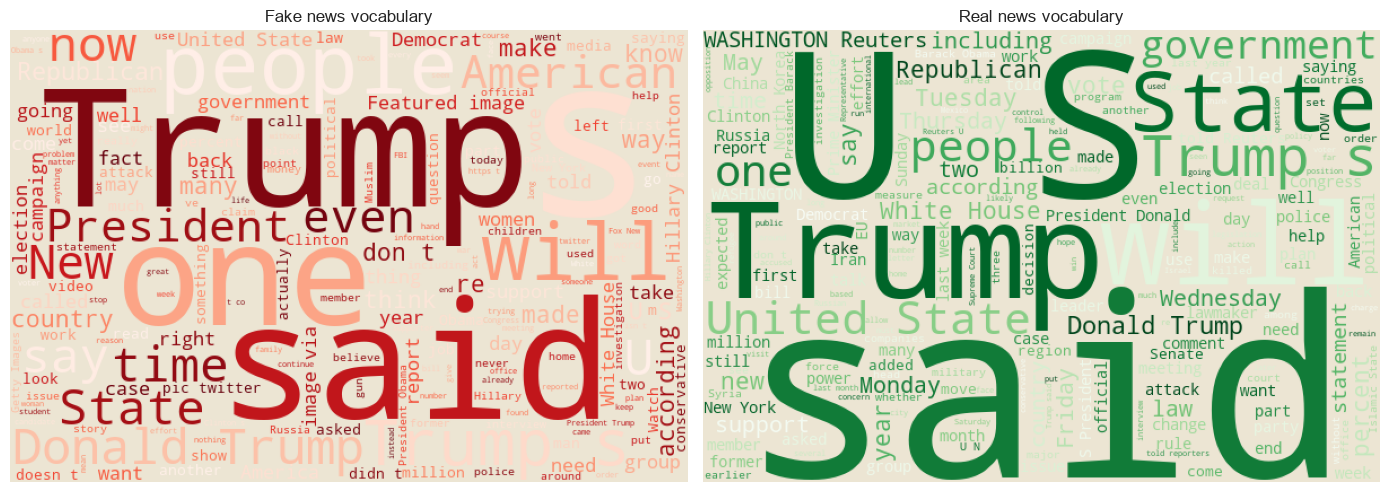

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

fake_text = " ".join(fake["text"].sample(3000, random_state=1).astype(str))
true_text = " ".join(true["text"].sample(3000, random_state=1).astype(str))

wc_fake = WordCloud(width=600, height=400, background_color="#ece5d3", colormap="Reds").generate(fake_text)
wc_true = WordCloud(width=600, height=400, background_color="#ece5d3", colormap="Greens").generate(true_text)

axes[0].imshow(wc_fake); axes[0].axis("off"); axes[0].set_title("Fake news vocabulary")
axes[1].imshow(wc_true); axes[1].axis("off"); axes[1].set_title("Real news vocabulary")
plt.tight_layout()
plt.show()


**Note:** the word "Reuters" dominates the real-news cloud purely because of the
byline leakage discussed in section 4 — another confirmation that it must be
stripped before training.

## 8. Publication date range

In [11]:
print("Fake date sample:", fake['date'].sample(3, random_state=1).tolist())
print("True date sample:", true['date'].sample(3, random_state=1).tolist())


Fake date sample: ['Mar 17, 2017', 'April 13, 2016', 'Dec 1, 2016']
True date sample: ['December 2, 2017 ', 'September 29, 2017 ', 'November 23, 2017 ']


## Summary of EDA findings → decisions carried into notebook 02

1. **Class balance is reasonable** (~52/48) → no need for SMOTE/class-weighting, but still report precision/recall per class.
2. **`subject` column is leakage** → dropped entirely, never used as a feature.
3. **`"(Reuters) -"` byline is leakage** → stripped during text cleaning.
4. **Punctuation/capitalization differs by class** → engineered as handcrafted features (exclamation count, uppercase word count) alongside TF-IDF.
5. **Duplicate (title, text) rows exist** → dropped before train/test split.
6. **Text length differs somewhat by class** → `word_count`/`char_count` also engineered as features.

→ Continue to **`02_feature_engineering_and_modeling.ipynb`**.